# Analysis and Prediction of Used Car Prices

The dataset explored in this project contains over 90,000 entries of used car data scraped from the British market.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, make_scorer, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
df = pd.read_csv("CarsData.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,I10,2017,7495,Manual,11630,Petrol,145,60.1,1.0,hyundi
1,Polo,2017,10989,Manual,9200,Petrol,145,58.9,1.0,volkswagen
2,2 Series,2019,27990,Semi-Auto,1614,Diesel,145,49.6,2.0,BMW
3,Yeti Outdoor,2017,12495,Manual,30960,Diesel,150,62.8,2.0,skoda
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.3,1.2,ford


## Data Profiling:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97712 entries, 0 to 97711
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         97712 non-null  object 
 1   year          97712 non-null  int64  
 2   price         97712 non-null  int64  
 3   transmission  97712 non-null  object 
 4   mileage       97712 non-null  int64  
 5   fuelType      97712 non-null  object 
 6   tax           97712 non-null  int64  
 7   mpg           97712 non-null  float64
 8   engineSize    97712 non-null  float64
 9   Manufacturer  97712 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 7.5+ MB


In [4]:
print('Number of duplicated rows:', df.duplicated().sum())

Number of duplicated rows: 0


In [5]:
df.isna().sum().to_frame(name='Count of Null Values')

,Count of Null Values
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0
Manufacturer,0


In [6]:
df.nunique().to_frame(name='Count of Unique Values')

,Count of Unique Values
model,196
year,27
price,13236
transmission,4
mileage,42214
fuelType,5
tax,48
mpg,208
engineSize,40
Manufacturer,9


In [7]:
print('Unique transmission types:', df['transmission'].unique())
print('Unique fuel types:', df['fuelType'].unique())
print('Unique manufacturers:', df['Manufacturer'].unique())

Unique transmission types: ['Manual' 'Semi-Auto' 'Automatic' 'Other']
Unique fuel types: ['Petrol' 'Diesel' 'Hybrid' 'Other' 'Electric']
Unique manufacturers: ['hyundi' 'volkswagen' 'BMW' 'skoda' 'ford' 'toyota' 'merc' 'vauxhall'
 'Audi']


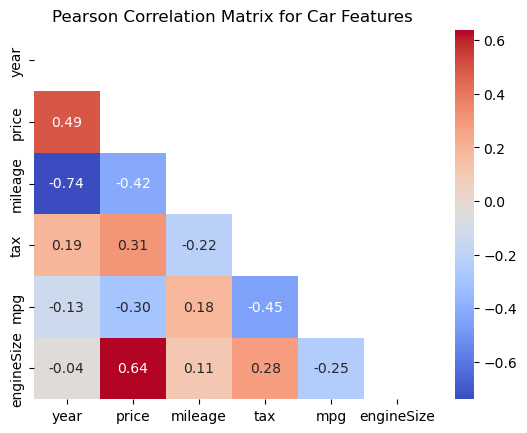

In [8]:
correlation_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix for Car Features')
plt.show()

In [9]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000
mean,2017.066502,16773.487555,23219.475499,120.142408,55.205623,1.664913
std,2.118661,9868.552222,21060.882301,63.357250,16.181659,0.558574
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000
50%,2017.000000,14470.000000,17682.500000,145.000000,54.300000,1.600000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000
max,2024.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


## Data Cleaning:

Capitalize the manufacturer names.

In [10]:
df['Manufacturer'] = df['Manufacturer'].str.capitalize()
df['Manufacturer'] = df['Manufacturer'].replace({'Bmw': 'BMW', 'Merc': 'Mercedes'})

Inspect rows where engine size = 0

In [11]:
df[df['engineSize']==0]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
449,i3,2017,19895,Automatic,29851,Hybrid,0,470.8,0.0,BMW
969,i3,2016,14900,Automatic,59945,Hybrid,0,470.8,0.0,BMW
1985,3 Series,2018,18000,Automatic,24240,Diesel,150,64.2,0.0,BMW
2219,Astra,2017,11000,Manual,14878,Petrol,145,51.4,0.0,Vauxhall
3290,I10,2015,7500,Manual,13637,Petrol,30,57.6,0.0,Hyundi
...,...,...,...,...,...,...,...,...,...,...
95623,Fiesta,2018,12999,Manual,15000,Petrol,150,58.9,0.0,Ford
95625,I20,2017,11400,Automatic,12661,Petrol,145,44.1,0.0,Hyundi
96910,Mondeo,2013,5328,Manual,105000,Diesel,30,65.7,0.0,Ford
97033,I10,2016,6300,Manual,17272,Petrol,20,61.4,0.0,Hyundi


Listings with zero engine size are corrupt or missing data and we will remove them.

In [12]:
print('Number of listings where engine size = 0 is', (df['engineSize'] == 0).sum())
df = df[df['engineSize'] != 0]

Number of listings where engine size = 0 is 268


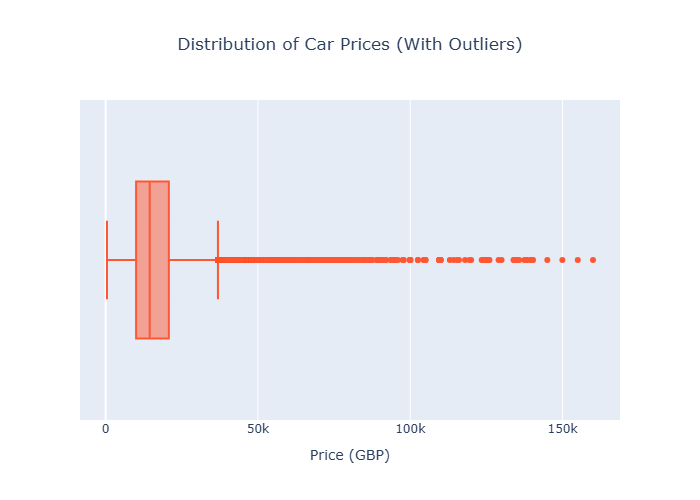

In [13]:
fig = px.box(
    df,
    x='price',
    title='Distribution of Car Prices (With Outliers)',
    color_discrete_sequence=['#FF5733']
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Price (GBP)'
)

# Render as a static image since GitHub does not support interactive Plotly plots
fig.show(renderer="png")

Group the prices into 3 categories for later classification. Most prices fall between 10k and 20k.

In [14]:
df = df.copy()

bins = [0, 10000, 20000, float('inf')]
labels = ['Under 10k', '10k-20k', 'Over 20k']

df['price_group'] = pd.cut(
    df['price'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

df['price_group'].value_counts().to_frame(name='Car Count')

,Car Count
price_group,
10k-20k,47019
Over 20k,25922
Under 10k,24503


Remove outlier prices.

In [15]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['price'] < lower_bound) | (df['price'] > upper_bound)
]

df_filtered = df[
    (df['price'] >= lower_bound) & (df['price'] <= upper_bound)
]

In [16]:
print('Number of outliers:', outliers.shape[0])
print(f"The outliers represent {(outliers.shape[0]/df.shape[0]):.1%} of the original dataset.")

Number of outliers: 3810
The outliers represent 3.9% of the original dataset.


Descriptive statistics after filtering outliers:

In [17]:
df_filtered.describe()

,year,price,mileage,tax,mpg,engineSize
count,93634.000000,93634.000000,93634.000000,93634.000000,93634.000000,93634.000000
mean,2016.991851,15477.050025,23899.238236,118.755260,55.738123,1.619899
std,2.113346,7159.375750,21165.854213,63.363065,13.540781,0.483888
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.600000
25%,2016.000000,9995.000000,8403.000000,125.000000,47.100000,1.200000
50%,2017.000000,13995.000000,18524.500000,145.000000,55.400000,1.500000
75%,2019.000000,19899.000000,33145.000000,145.000000,62.800000,2.000000
max,2024.000000,36875.000000,323000.000000,580.000000,470.800000,6.300000


## Data Visualization and Analysis:

### Plot 1: Distribution of Car Prices

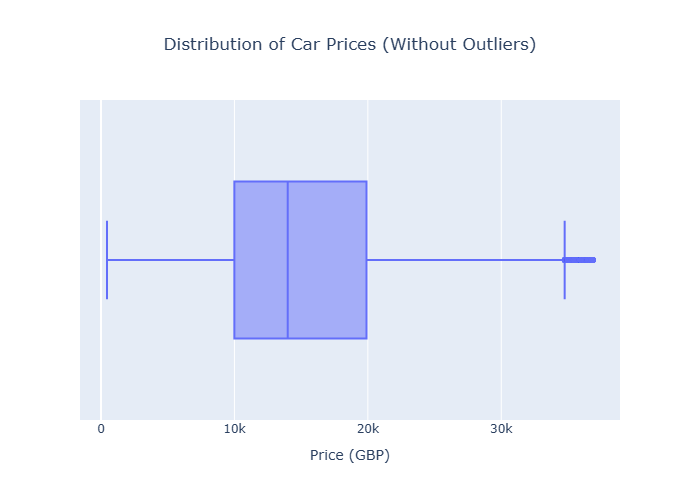

In [18]:
fig = px.box(
    df_filtered,
    x='price',
    title='Distribution of Car Prices (Without Outliers)'
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Price (GBP)'
)

fig.show(renderer="png")

### Plot 2: Model Year vs. Average Price

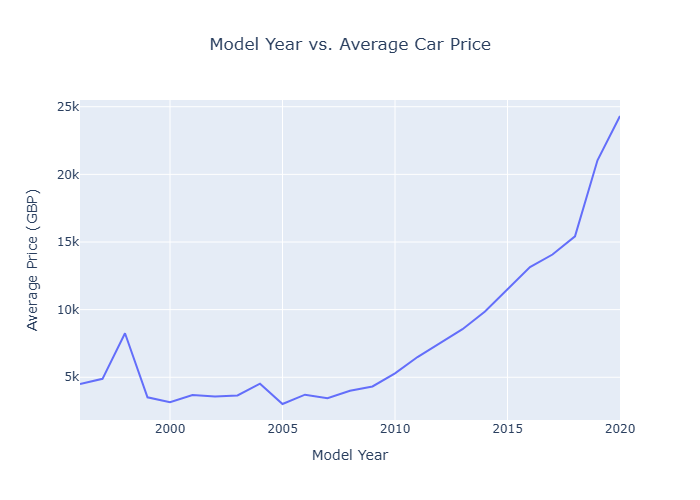

In [19]:
avg_price = (
    df_filtered[(df_filtered['year'] > 1970) & (df_filtered['year'] < 2024)]
    .groupby('year')['price']
    .mean()
    .reset_index()
)

fig = px.line(
    avg_price,
    x='year',
    y='price',
    title='Model Year vs. Average Car Price',
    labels={'year': 'Model Year', 'price': 'Average Price (GBP)'}
)

fig.update_layout(title_x=0.5, showlegend=False)
fig.show(renderer="png")

### Plot 3: Average Price by Manufacturer

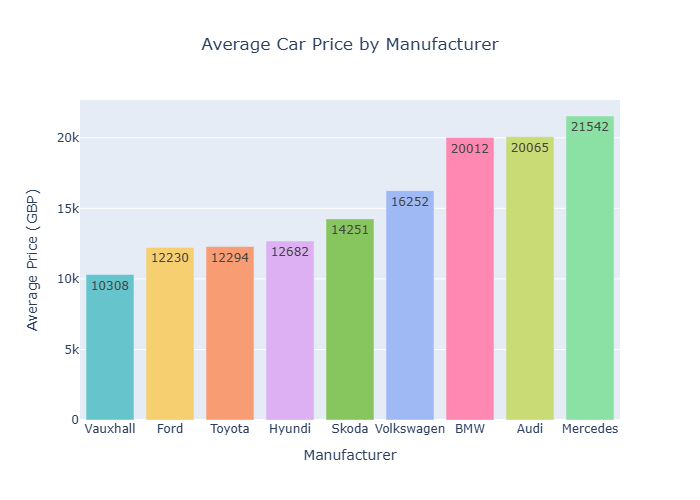

In [20]:
avg_price = (
    df_filtered
    .groupby('Manufacturer')['price']
    .mean()
    .reset_index()
    .sort_values(by='price', ascending=True)
)

fig = px.bar(
    avg_price,
    x='Manufacturer',
    y='price',
    color='Manufacturer',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='Average Car Price by Manufacturer',
    labels={'Manufacturer': 'Manufacturer', 'price': 'Average Price (GBP)'},
    text_auto='.0f'
)

fig.update_layout(title_x=0.5, showlegend=False)
fig.show(renderer="png")

### Plot 4: Average Price by Transmission Type

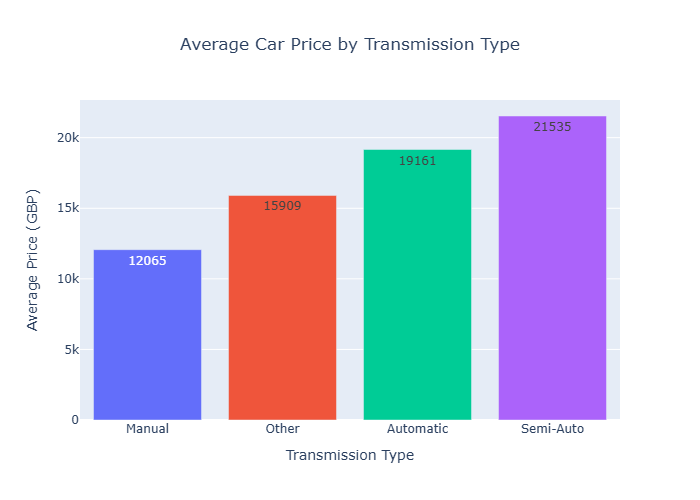

In [21]:
avg_price = (
    df_filtered
    .groupby('transmission')['price']
    .mean()
    .reset_index()
    .sort_values(by='price', ascending=True)
)

fig = px.bar(
    avg_price,
    x='transmission',
    y='price',
    color='transmission',
    title='Average Car Price by Transmission Type',
    labels={'transmission': 'Transmission Type', 'price': 'Average Price (GBP)'},
    text_auto='.0f'
)

fig.update_layout(title_x=0.5, showlegend=False)
fig.show(renderer="png")

### Plot 5: Average Price by Engine Size

In [22]:
df_filtered = df_filtered.copy()

bins = [0, 1, 1.5, 2, 2.5, 3, float('inf')]
labels = ['≤1', '1.1–1.5', '1.6–2', '2.1–2.5', '2.6–3', '>3']

df_filtered['engineSize_group'] = pd.cut(
    df_filtered['engineSize'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

df_filtered['engineSize_group'].value_counts().to_frame(name='Car Count')

,Car Count
engineSize_group,
1.6–2,37332
1.1–1.5,30685
≤1,17090
2.1–2.5,5018
2.6–3,3306
>3,203


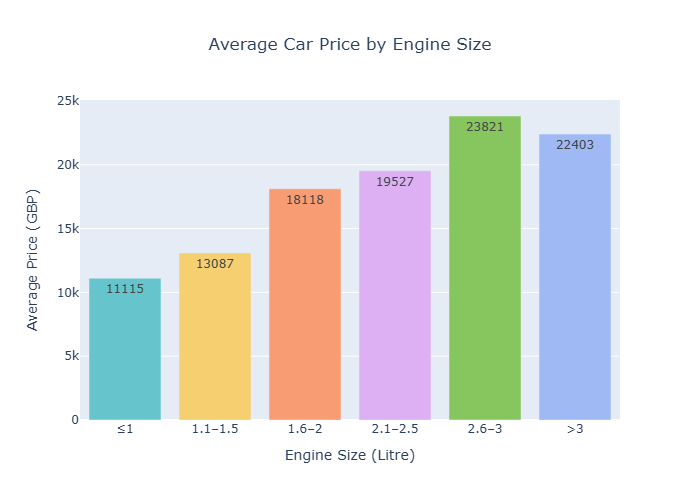

In [23]:
avg_price = (
    df_filtered
    .groupby('engineSize_group', observed=False)['price']
    .mean()
    .reset_index()
)

fig = px.bar(
    avg_price,
    x='engineSize_group',
    y='price',
    color='engineSize_group',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='Average Car Price by Engine Size',
    labels={'engineSize_group': 'Engine Size (Litre)', 'price': 'Average Price (GBP)'},
    text_auto='.0f'
)

fig.update_layout(title_x=0.5, showlegend=False)
fig.show(renderer="png")

### Plot 6: Average Price by Fuel Type

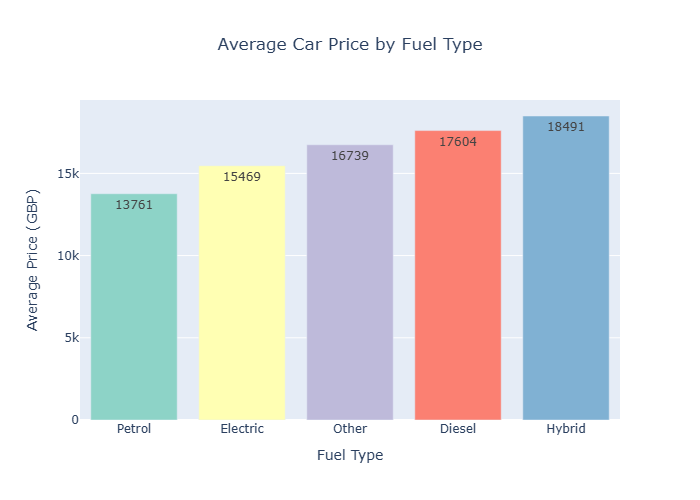

In [24]:
avg_price = (
    df_filtered
    .groupby('fuelType')['price']
    .mean()
    .reset_index()
    .sort_values(by='price', ascending=True)
)

fig = px.bar(
    avg_price,
    x='fuelType',
    y='price',
    color='fuelType',
    color_discrete_sequence=px.colors.qualitative.Set3,
    title='Average Car Price by Fuel Type',
    labels={'fuelType': 'Fuel Type', 'price': 'Average Price (GBP)'},
    text_auto='.0f'
)

fig.update_layout(title_x=0.5, showlegend=False)
fig.show(renderer="png")

### Plot 7: Mileage vs. Car Price

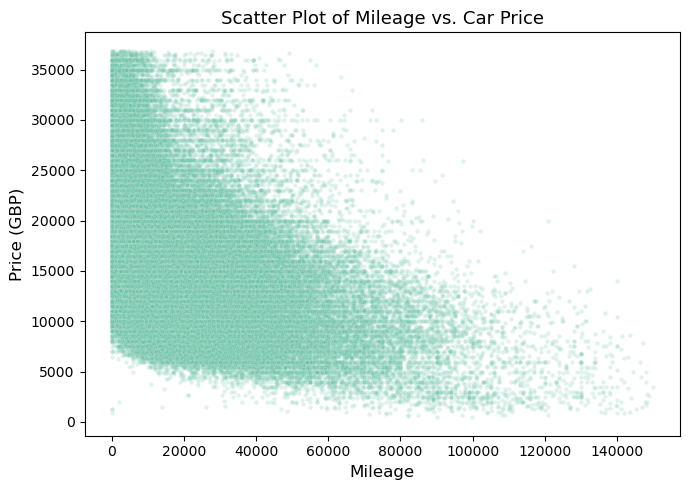

In [25]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df_filtered[df_filtered['mileage'] < 150000],
    x='mileage',
    y='price',
    color=sns.color_palette('Set2')[0],
    alpha=0.2,
    s=10
)

plt.title('Scatter Plot of Mileage vs. Car Price', fontsize=13)
plt.xlabel('Mileage', size=12)
plt.ylabel('Price (GBP)', size=12)
plt.tight_layout()
plt.show()

### Prediction of Car Prices

#### Linear Regression

In [26]:
df_model = df_filtered
df_model = df_model[
    ['year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Manufacturer', 'price']
]

# Encode the categorical variables
df_encoded = pd.get_dummies(
    df_model, columns=['fuelType', 'transmission', 'Manufacturer']
)

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

lin_reg_model = LinearRegression()

# Apply K-fold cross-validation for robust evaluation of the model's performance
k_fold = KFold(n_splits=5, shuffle=True, random_state=1)

scores = {
    'r2': 'r2',
    'rmse': make_scorer(root_mean_squared_error),
    'mae': make_scorer(mean_absolute_error)
}

lin_reg_results = cross_validate(
    lin_reg_model,
    X, y,
    cv=k_fold,
    scoring=scores,
    return_train_score=False
)

print('\n*** Linear Regression Model Evaluation ***\n')
print(f"Average R²:   {lin_reg_results['test_r2'].mean():.3f}")
print(f"Average RMSE: {lin_reg_results['test_rmse'].mean():.0f} GBP")
print(f"Average MAE:  {lin_reg_results['test_mae'].mean():.0f} GBP")


*** Linear Regression Model Evaluation ***

Average R²:   0.821
Average RMSE: 3028 GBP
Average MAE:  2262 GBP


#### Random Forest Regression

In [27]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

rf_model = RandomForestRegressor(n_estimators=300, random_state=1)

k_fold = KFold(n_splits=5, shuffle=True, random_state=1)

scores = {
    'r2': 'r2',
    'rmse': make_scorer(root_mean_squared_error),
    'mae': make_scorer(mean_absolute_error)
}

rf_results = cross_validate(
    rf_model,
    X, y,
    cv=k_fold,
    scoring=scores,
    return_train_score=False
)

print('\n*** Random Forest Regression Model Evaluation ***\n')
print(f"Average R²:   {rf_results['test_r2'].mean():.3f}")
print(f"Average RMSE: {rf_results['test_rmse'].mean():.0f} GBP")
print(f"Average MAE:  {rf_results['test_mae'].mean():.0f} GBP")


*** Random Forest Regression Model Evaluation ***

Average R²:   0.941
Average RMSE: 1732 GBP
Average MAE:  1179 GBP


Visualize how the Random Forest regression model performs on a single train/test split.

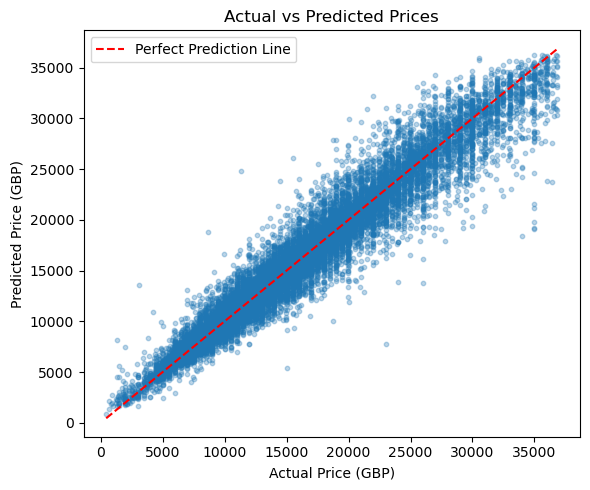

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction Line')
plt.xlabel("Actual Price (GBP)")
plt.ylabel("Predicted Price (GBP)")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.tight_layout()
plt.show()

### Prediction of Price Ranges (Classification)

Use **logistic regression** to predict the price category of the car ("Under 10k", "10k-20k", "Over 20k")

In [29]:
X = df.drop(['price', 'price_group', 'model'], axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df['price_group']

# Standardize the data
log_reg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=10000, class_weight=None)
)

# Stratify the folds to avoid class imbalance in the folds
str_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

scoring_metrics = {
    'Accuracy': 'accuracy',
    'Precision': 'precision_macro',
    'Recall': 'recall_macro',
    'f1': 'f1_macro'
}

log_reg_results = cross_validate(
    log_reg_model, X, y, cv=str_k_fold, scoring=scoring_metrics
)

print('\n*** Logistic Regression Model Evaluation ***\n')
for metric in scoring_metrics.keys():
    avg_score = log_reg_results[f'test_{metric}'].mean()
    print(f"Average {metric}: {avg_score:.3f}")


*** Logistic Regression Model Evaluation ***

Average Accuracy: 0.829
Average Precision: 0.834
Average Recall: 0.824
Average f1: 0.829


Compute a confusion matrix for a single train/test split.

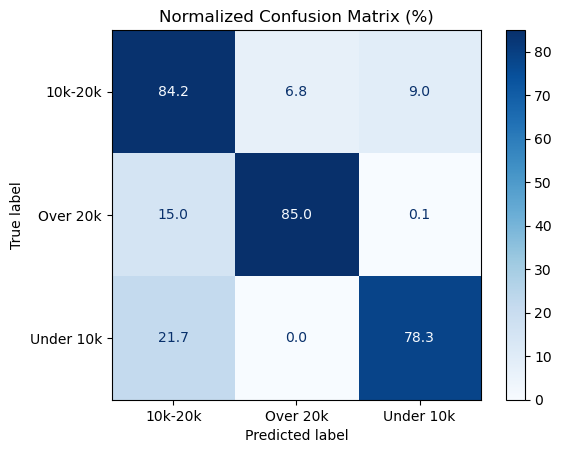

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

log_reg_model.fit(X_train, y_train)
y_pred = log_reg_model.predict(X_test)

confusion_matrix = confusion_matrix(y_test, y_pred, labels=log_reg_model.classes_, normalize='true')

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix*100, display_labels=log_reg_model.classes_
)

disp.plot(cmap='Blues', values_format='.1f')
plt.title("Normalized Confusion Matrix (%)")
plt.show()